In [51]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split


In [4]:
data=load_iris()
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

Since the output is truncated we will need to combine the features with the target to make our `Dataframe` fit for the data manipulation 

In [8]:
data.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [10]:
iris_df = pd.DataFrame(data.data, columns=data.feature_names)
iris_df['target'] = data.target
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Exploratory Data Analysis

In [16]:
iris_df.shape

(149, 5)

I used the `sklearn.datasets.load_iris()` function to load the Iris dataset. I then created a pandas DataFrame called iris_df using the data and feature names from the dataset. I also added a 'target' column to the DataFrame to represent the species of each iris flower. Finally, I displayed the first few rows of the DataFrame using the head() method and checked the information about the DataFrame using the info() method.

In [11]:
iris_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [13]:
iris_df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [14]:
iris_df.duplicated().sum()


np.int64(1)

There is one duplicated observation that must be removed tyo avoid repetition.

In [15]:
iris_df.drop_duplicates(inplace=True)

In [17]:
iris_df.shape

(149, 5)

Initially we had 150 observations after dropping the duplicate row we end up with `149` due to the argument `inplace True` that altered the dataframe.

# Data Visualization

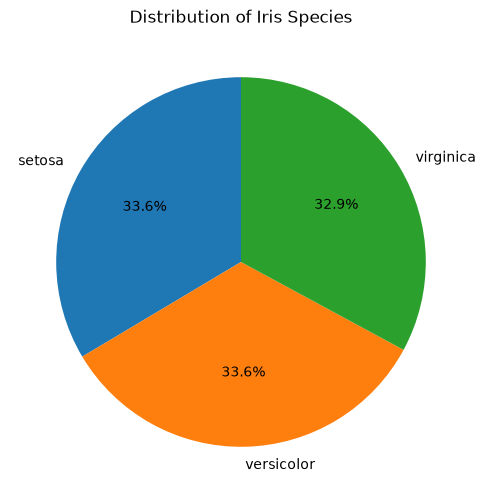

In [25]:
plt.figure(figsize=(10,6))
plt.title('Distribution of Iris Species')
plt.pie(iris_df['target'].value_counts(), labels=data.target_names, autopct='%1.1f%%', startangle=90)

The target is well balance there is no class that is underrepresented so we won't need to resample our dataset to deal with any case of class imbalance.


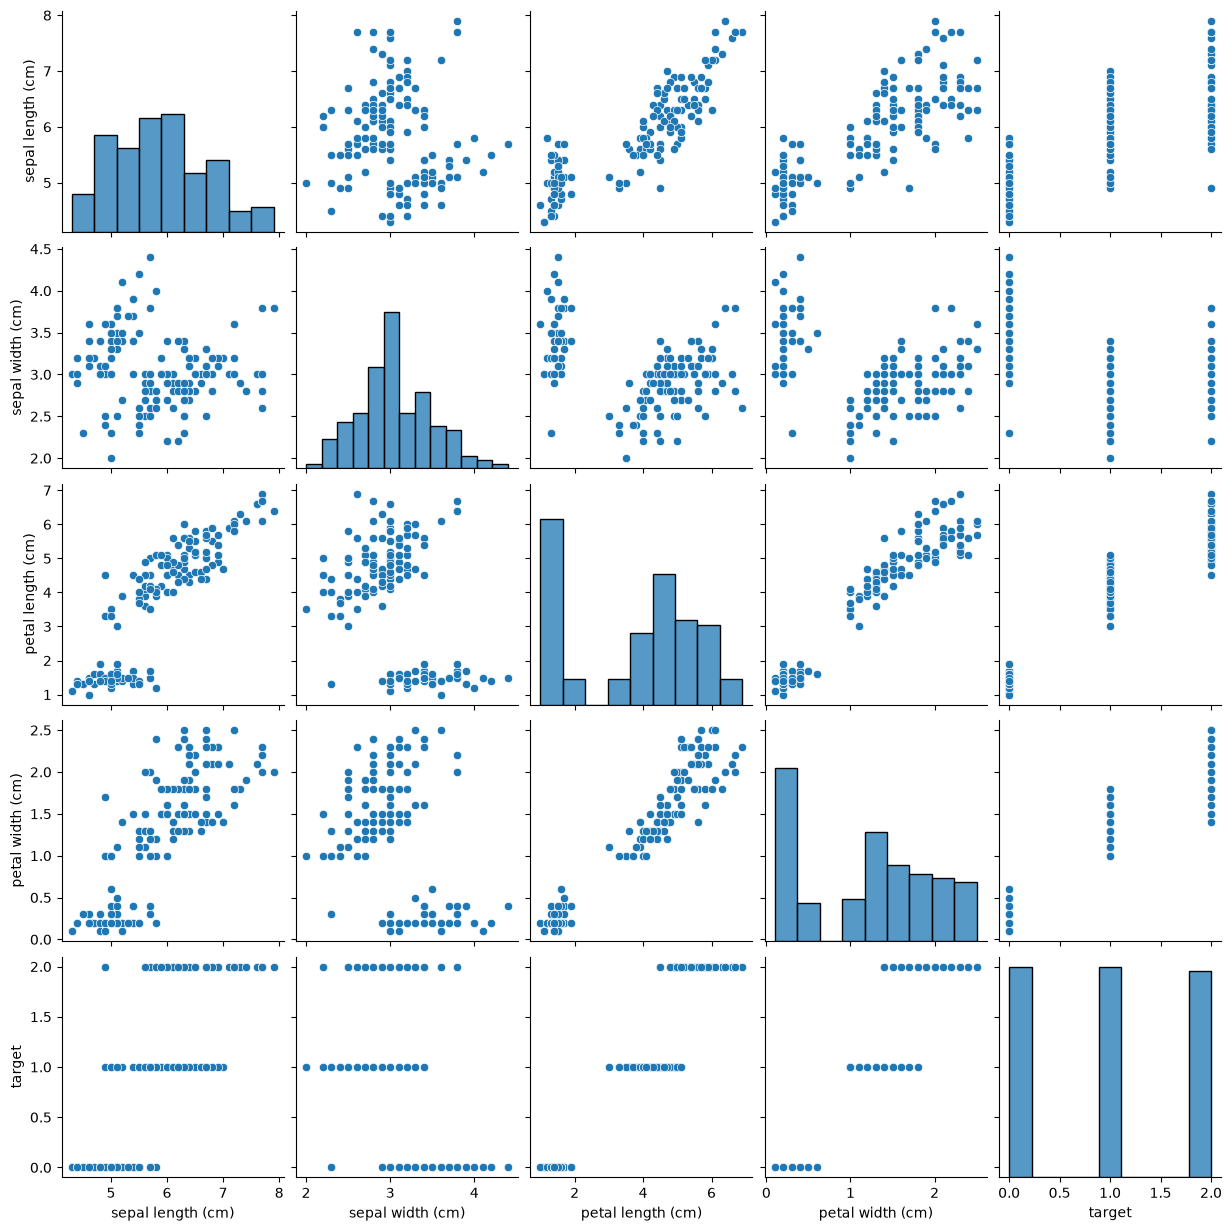

In [34]:
sns.pairplot(iris_df)

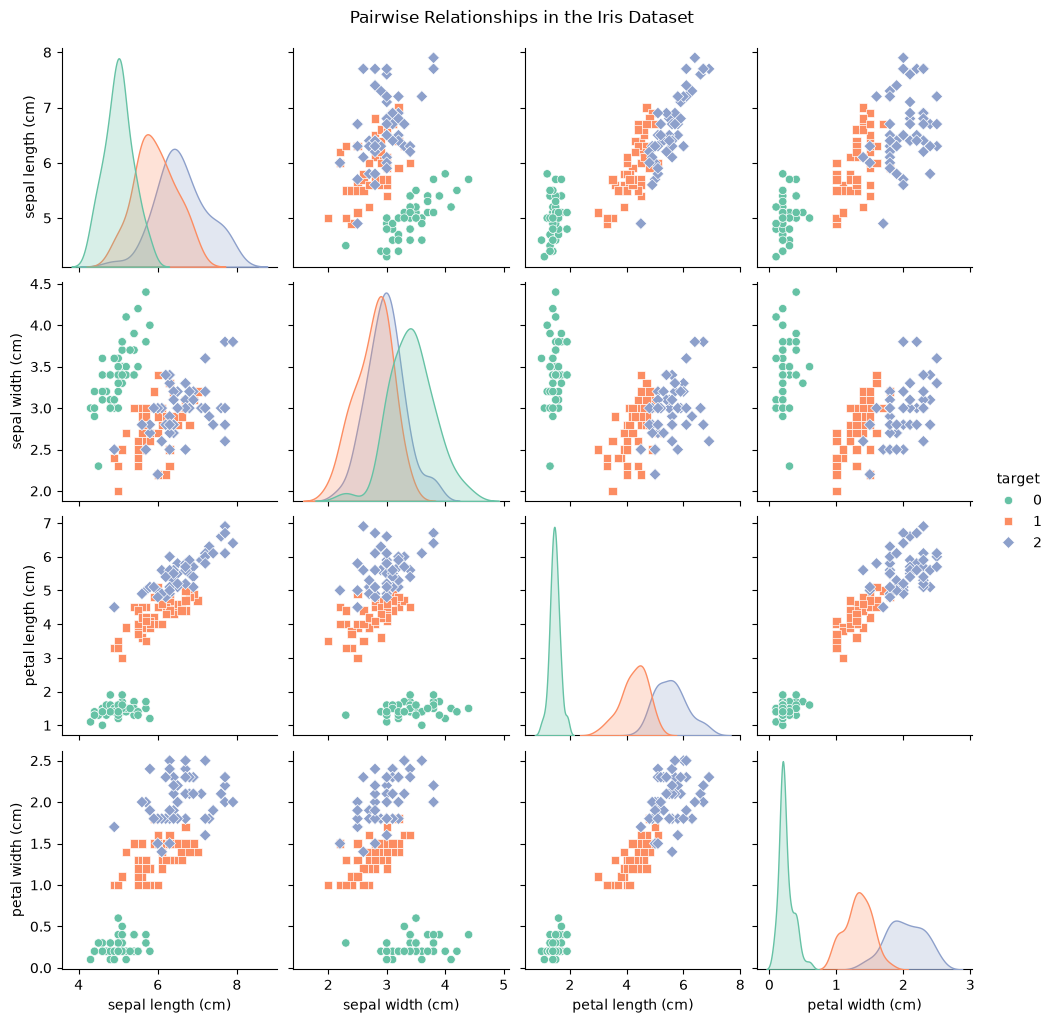

In [30]:
g = sns.pairplot(iris_df, hue='target', palette='Set2', markers=["o", "s", "D"])
g.fig.suptitle('Pairwise Relationships in the Iris Dataset', y=1.02)
plt.show()

There is a well defined stratification of the 3 target classes.There is no overlapping in the 3 different classes making the task ideal for categorical classification.

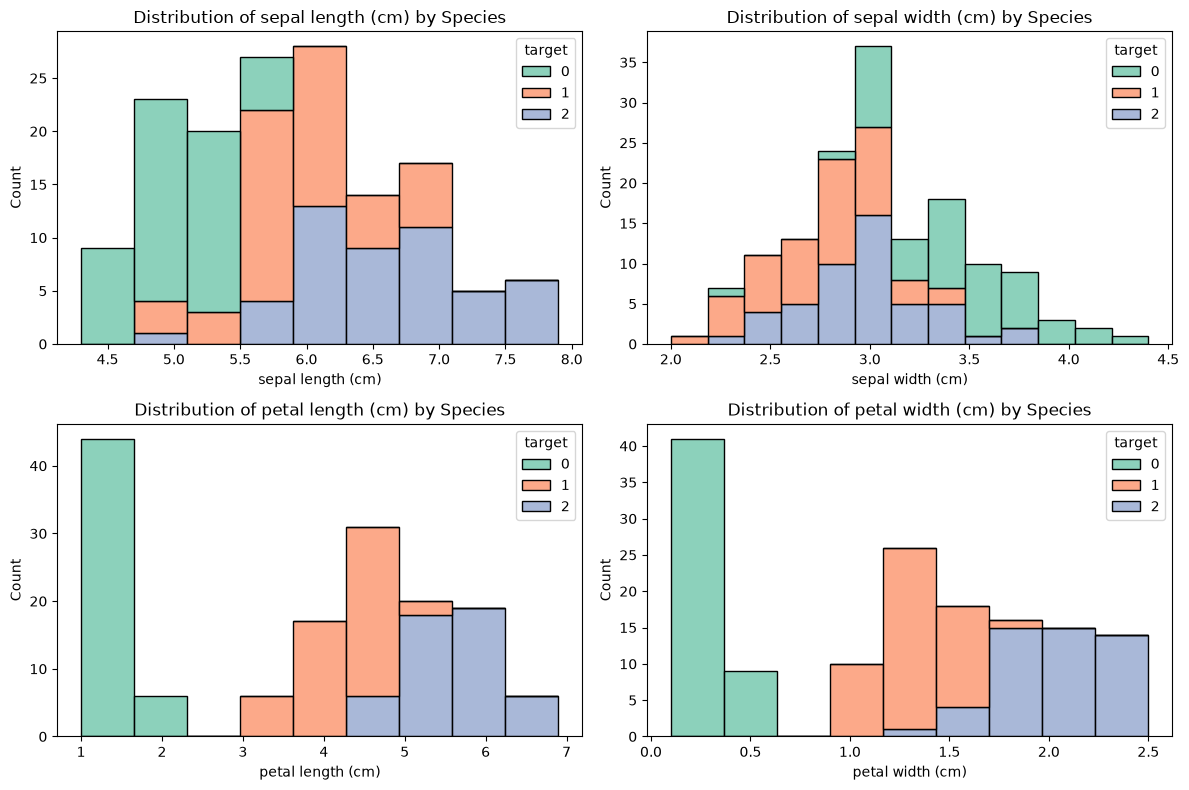

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(iris_df.columns[:-1]):  # Exclude the target column
    sns.histplot(data=iris_df, x=col, hue='target', multiple='stack', palette='Set2', ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Species')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [45]:
iris_df_drop = iris_df.drop('target', axis=1)

In [46]:
iris_corr = iris_df_drop.corr()
iris_corr

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.118129,0.873738,0.820620
sepal width (cm),-0.118129,1.000000,-0.426028,-0.362894
petal length (cm),0.873738,-0.426028,1.000000,0.962772
petal width (cm),0.820620,-0.362894,0.962772,1.000000


<Axes: >

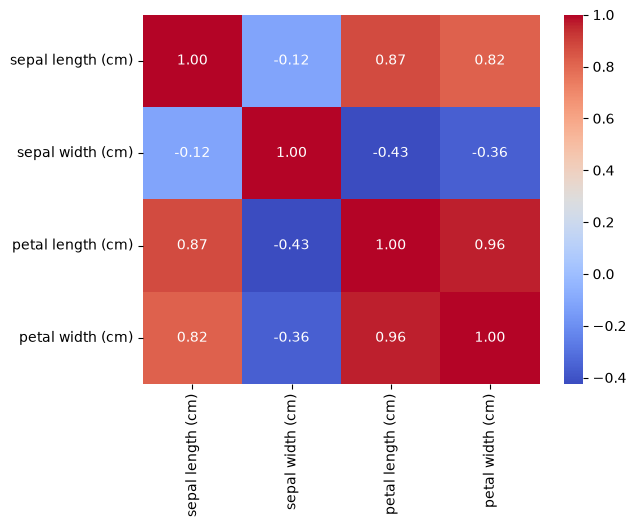

In [47]:
sns.heatmap(iris_corr, annot=True, cmap='coolwarm', fmt=".2f")

# Data Cleaning

Since our data quality is okay since the only issue was the duplicate and we drop the duplicates we may proceed to the next Machine Learning step in problem solving which is Feature Selection.

# Feature Selection

There features are highly correlated having lots of information to contribute to the prediction of the model.


In [50]:
X=iris_df.drop('target', axis=1) # dropping the target column from the dataset to create the feature set
Y=iris_df['target']

### Data splitting into the training and testing size

In [53]:
x_train,x_test,y_train,y_test=train_test_split(X,Y, test_size=0.2, random_state=42)


In [59]:
print(f"Training feature size:{len(x_train)} samples")
print(F"Test feature size is:{len(x_test)} samples")
print(F"Training target size is :{len(y_train)} samples")
print(F"Test target size is:{len(y_test)}samples")

Training feature size:119 samples
Test feature size is:30 samples
Training target size is :119 samples
Test target size is:30samples


# Model Selection


Since we have a categorical target well defined or stratified target we have a classification task with a wide range of models at our disposal for our use. We will test several model families on our cleaned dataset. Since our target are `3` classes we can use the logistic regression which will automatically detect the multiclass. We will use `Logistic Regression` as the base model representing the `linear models`. `Random Forest` for the ensemble family, `Decsion Tree` for the tree family, `Xgboost` for the Gradient boosting family and `K-Nearest Neighbors` for the neighbors.